In [3]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

$$
G(s)=\frac{1}{s(s+B)}=\frac{1}{s^2+0.5s}
$$

In [4]:
def Gs(B):
    return ctrl.TransferFunction([1], [1, B, 0])

# Parte A - Analisis de Sensibilidad y Robustez

### a.

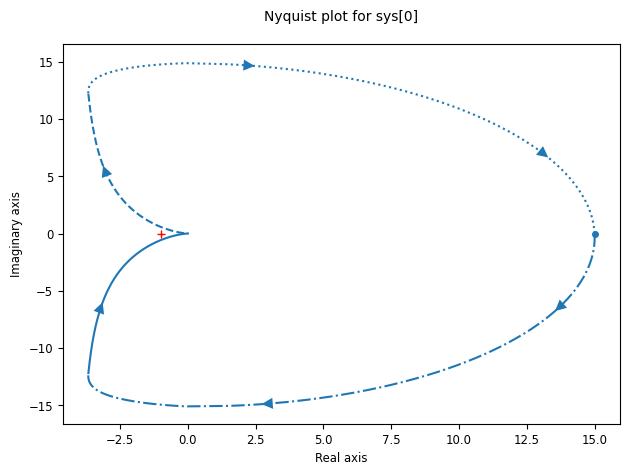

In [5]:
G = Gs(0.5)

# Diagrama de Nyquist
plt.figure()
ctrl.nyquist_plot(G)
plt.title('')
plt.grid()
plt.show()

$$
Z = N + P
$$

Donde:

$$
N = 0
\quad\text{(ninguna vuelta alrededor de }(-1,0)\text{)}
$$

$$
P = 0
\quad\text{(}G(s)\text{ no tiene polos en el semiplano derecho estricto}
$$

Por lo tanto:

$$
Z = 0 + 0 = 0
$$

Conclusión: el sistema en lazo cerrado es estable con B = 0.5.

### b.

/home/juan/miniconda3/envs/dev/lib/python3.11/site-packages/control/timeresp.py:1088: UserWarning: Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.
  warnings.warn(


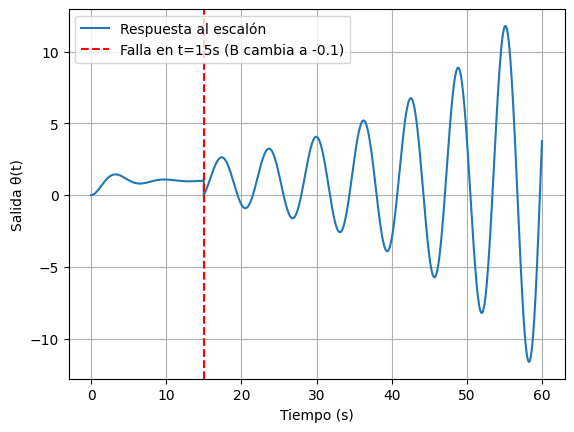

In [6]:
# Tramo 1
G1 = Gs(0.5)
T1 = ctrl.feedback(G1, 1)

t1 = np.linspace(0, 15, 1000)
t1, y1 = ctrl.step_response(T1, t1)

# Tramo 2
G2 = Gs(-0.1)
T2 = ctrl.feedback(G2, 1)

t2 = np.linspace(15, 60, 1000)
X0 = np.array([y1[-1], 0])  # Condición inicial para el tramo 2
t2, y2 = ctrl.forced_response(T2, T=t2, U=np.ones_like(t2), X0=X0)

t = np.concatenate((t1, t2))
y = np.concatenate((y1, y2))

plt.figure()
plt.plot(t, y, label='Respuesta al escalón')
plt.axvline(x=15, color='r', linestyle='--', label='Falla en t=15s (B cambia a -0.1)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida θ(t)')
plt.legend()
plt.grid()
plt.show()

SUPER INESTABLE NOOOO

### c.

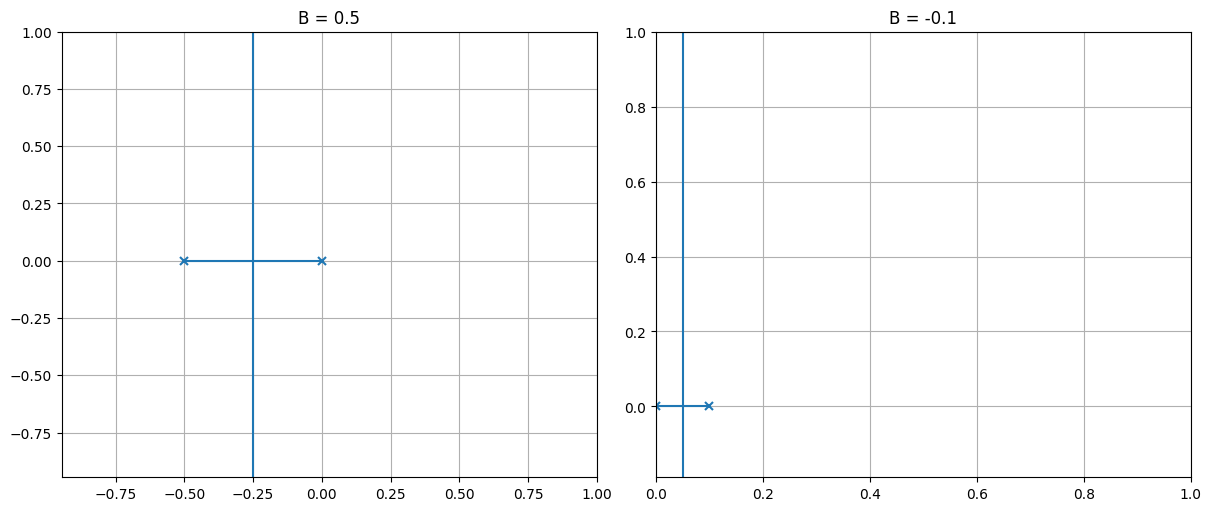

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ctrl.root_locus_plot(G1, ax=axes[0])
axes[0].set_title('B = 0.5')
axes[0].grid(True)

ctrl.root_locus_plot(G2, ax=axes[1])
axes[1].set_title('B = -0.1')
axes[1].grid(True)

plt.show()

### d.

G1 = B = 0.5
  Margen de ganancia: inf
  Margen de fase: 28.02017611933482

G2 = B = -0.1
  Margen de ganancia: inf
  Margen de fase: -5.724792592138272



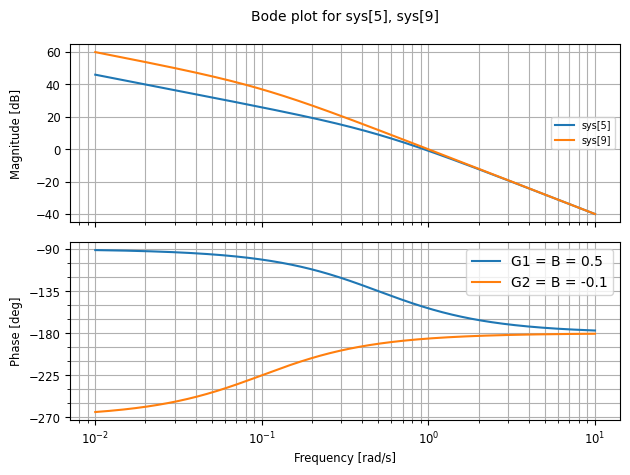

In [8]:
gm1, pm1, wg1, wp1 = ctrl.margin(G1)
gm2, pm2, wg2, wp2 = ctrl.margin(G2)

print("G1 = B = 0.5")
print(f"  Margen de ganancia: {gm1}")
print(f"  Margen de fase: {pm1}")
print()

print("G2 = B = -0.1")
print(f"  Margen de ganancia: {gm2}")
print(f"  Margen de fase: {pm2}")
print()

plt.figure()
ctrl.bode_plot([G1, G2], dB=True)
plt.legend(["G1 = B = 0.5", "G2 = B = -0.1"])
plt.show()

Margen de Fase es negativo cuando B = -0.1 entonces deberiamos usar un compensador lead para que aporte fase positiva para aumentar el margen de fase del sistema. 

# Parte B - Diseño de Compensador para Estabilidad Robusta

### Compensador Lead:

$$
C(s)=K_c\,\frac{s+\frac{1}{T}}{s+\frac{1}{\alpha T}}, 
\qquad 0<\alpha<1
$$

Definiendo
$$
z=\frac{1}{T}, 
\qquad 
p=\frac{1}{\alpha T},
$$
se obtiene
$$
z=\alpha\,p.
$$

Si se normaliza la ganancia estática del compensador:
$$
C(0)=K_c\,\frac{\frac{1}{T}}{\frac{1}{\alpha T}}
=K_c\,\alpha=1
\;\Longrightarrow\;
K_c=\frac{1}{\alpha}.
$$

Para seleccionar $\alpha$, se usa la relación con el máximo adelanto de fase:
$$
\alpha=\frac{1-\sin\phi_{\max}}{1+\sin\phi_{\max}},
\qquad 0<\alpha<1.
$$

donde $\phi_{\max}$ es el aporte máximo de fase del compensador.

In [9]:
G = Gs(0.5)
gm, pm, wg, wp = ctrl.margin(G)

target_margins = [35, 50, 65]
print('Margen de fase:', pm)

for target in target_margins:
    print(f'Para un margen de fase objetivo de {target} grados, se necesita un aportador de fase de {target - pm:.2f} grados.')

Margen de fase: 28.02017611933482
Para un margen de fase objetivo de 35 grados, se necesita un aportador de fase de 6.98 grados.
Para un margen de fase objetivo de 50 grados, se necesita un aportador de fase de 21.98 grados.
Para un margen de fase objetivo de 65 grados, se necesita un aportador de fase de 36.98 grados.


Por lo tanto, se busca que el máximo adelanto de fase del compensador sea:

$$
\phi_{\max}=37^\circ
$$

Debido a perdidas posibles por desplazamientos, agregamos 10 grados de seguridad. 

Con esta elección se procede al cálculo de $\alpha$ en el diseño lead.

In [14]:
phi_max = 47  # grados, para el target mas exigente
phi_max_rad = np.radians(phi_max)
alpha = (1 - np.sin(phi_max_rad)) / (1 + np.sin(phi_max_rad))
print(f'alpha = {alpha:.4f}')

alpha = 0.1552


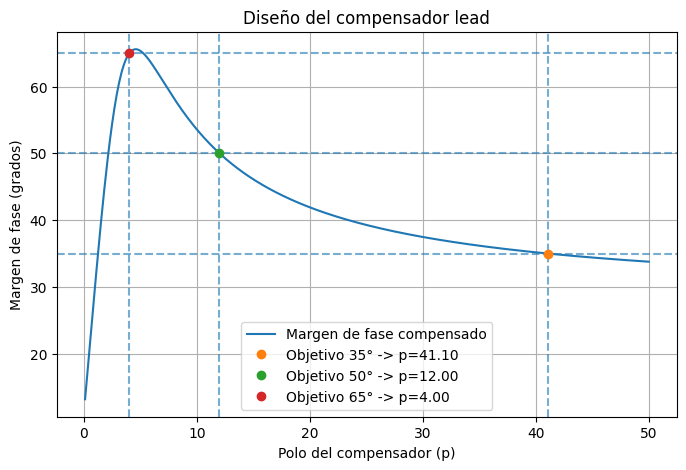

In [ ]:
possible_poles = np.linspace(0.1, 10, 500)
Kc = 1 / alpha

phase_margins = []
for p in possible_poles:
    z = alpha * p
    lead_tf = ctrl.TransferFunction([Kc, Kc * z], [1, p])
    pm = ctrl.margin(G * lead_tf)[1]
    phase_margins.append(pm if np.isfinite(pm) else np.nan)

phase_margins = np.array(phase_margins)

plt.figure(figsize=(8, 5))
plt.plot(possible_poles, phase_margins, label='Margen de fase compensado')

for target_pm in target_margins:
    idx = np.nanargmin(np.abs(phase_margins - target_pm))
    p_opt = possible_poles[idx]
    pm_opt = phase_margins[idx]

    plt.axhline(target_pm, linestyle='--', alpha=0.6)
    plt.axvline(p_opt, linestyle='--', alpha=0.6)
    plt.plot(p_opt, pm_opt, 'o', label=f'Objetivo {target_pm}° -> p={p_opt:.2f}')

plt.xlabel('Polo del compensador (p)')
plt.ylabel('Margen de fase (grados)')
plt.title('Diseño del compensador lead')
plt.grid(True)
plt.legend()
plt.show()
